In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import lightgbm as lgb

from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    roc_curve,
    precision_recall_curve,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report
)

print("Libraries imported successfully!")
print("LightGBM version:", lgb.__version__)

Libraries imported successfully!
LightGBM version: 4.7.0


In [2]:
import joblib

X_train_final = joblib.load(
    "../data/X_train_final_processed.pkl"
)

X_val_final = joblib.load(
    "../data/X_val_final_processed.pkl"
)

X_test_final = joblib.load(
    "../data/X_test_final_processed.pkl"
)

y_train = joblib.load(
    "../data/y_train_final.pkl"
)

y_val = joblib.load(
    "../data/y_val_final.pkl"
)

y_test = joblib.load(
    "../data/y_test_final.pkl"
)

print("Final datasets loaded!")

print("Train:", X_train_final.shape)
print("Validation:", X_val_final.shape)
print("Test:", X_test_final.shape)

print("y_train:", y_train.shape)
print("y_val:", y_val.shape)
print("y_test:", y_test.shape)

Final datasets loaded!
Train: (184506, 422)
Validation: (61502, 422)
Test: (61503, 422)
y_train: (184506,)
y_val: (61502,)
y_test: (61503,)


In [3]:
import numpy as np

X_train_full = np.vstack([
    X_train_final,
    X_val_final
])

y_train_full = np.concatenate([
    y_train,
    y_val
])

print("Combined training data:")
print("X:", X_train_full.shape)
print("y:", y_train_full.shape)

print("\nTarget distribution:")
print(pd.Series(y_train_full).value_counts())

Combined training data:
X: (246008, 422)
y: (246008,)

Target distribution:
0    226148
1     19860
Name: count, dtype: int64


In [4]:
final_model = lgb.LGBMClassifier(
    objective="binary",

    n_estimators=731,
    learning_rate=0.03,

    num_leaves=31,
    max_depth=-1,
    min_child_samples=50,

    subsample=0.8,
    colsample_bytree=0.8,

    reg_alpha=0.1,
    reg_lambda=1.0,

    random_state=42,
    n_jobs=-1
)

print("Final LightGBM model created!")

Final LightGBM model created!


In [5]:
final_model.fit(
    X_train_full,
    y_train_full
)

print("Final model training completed!")

[LightGBM] [Info] Number of positive: 19860, number of negative: 226148
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.103023 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 30783
[LightGBM] [Info] Number of data points in the train set: 246008, number of used features: 406
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.080729 -> initscore=-2.432482
[LightGBM] [Info] Start training from score -2.432482
Final model training completed!


In [6]:
y_test_proba = final_model.predict_proba(
    X_test_final
)[:, 1]

print("Test predictions generated!")

print("Number of predictions:", len(y_test_proba))

print("\nPrediction statistics:")
print("Minimum:", y_test_proba.min())
print("Maximum:", y_test_proba.max())
print("Mean:", y_test_proba.mean())

Test predictions generated!
Number of predictions: 61503

Prediction statistics:
Minimum: 0.002872126918489344
Maximum: 0.8682570215988423
Mean: 0.07946794412094561


In [7]:
test_roc_auc = roc_auc_score(
    y_test,
    y_test_proba
)

test_pr_auc = average_precision_score(
    y_test,
    y_test_proba
)

print("=" * 60)
print("FINAL TEST PERFORMANCE")
print("=" * 60)

print(f"ROC-AUC: {test_roc_auc:.6f}")
print(f"PR-AUC:  {test_pr_auc:.6f}")

FINAL TEST PERFORMANCE
ROC-AUC: 0.788418
PR-AUC:  0.280048


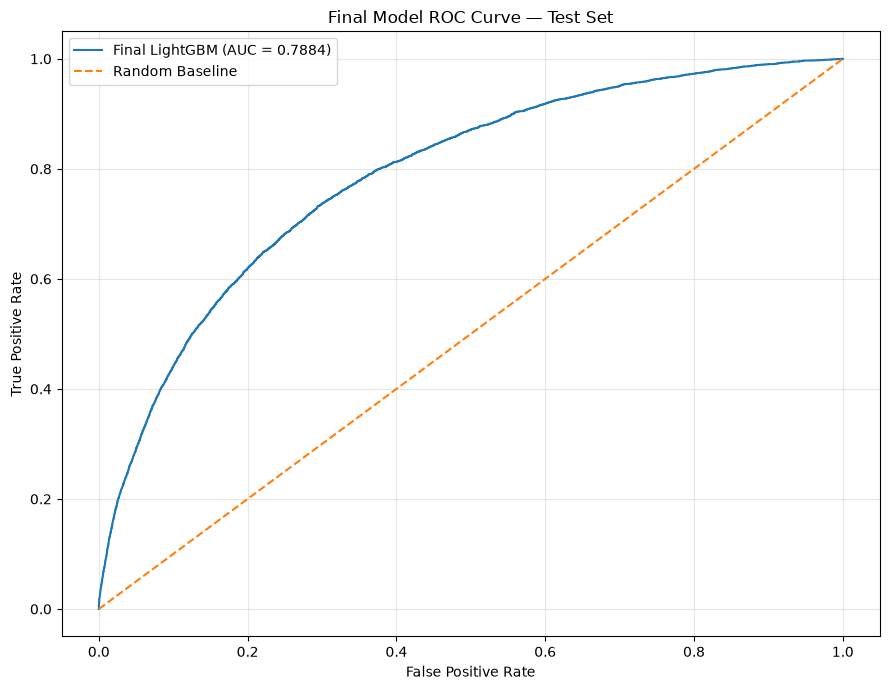

In [8]:
fpr, tpr, _ = roc_curve(
    y_test,
    y_test_proba
)

plt.figure(figsize=(9, 7))

plt.plot(
    fpr,
    tpr,
    label=f"Final LightGBM (AUC = {test_roc_auc:.4f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Baseline"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Final Model ROC Curve — Test Set")

plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

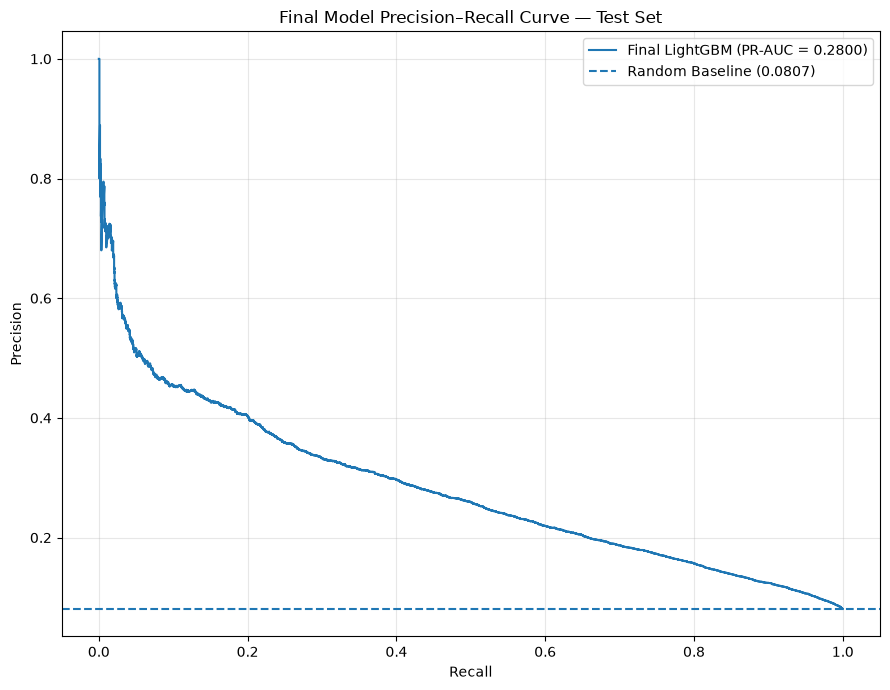

In [9]:
precision, recall, _ = precision_recall_curve(
    y_test,
    y_test_proba
)

baseline = y_test.mean()

plt.figure(figsize=(9, 7))

plt.plot(
    recall,
    precision,
    label=f"Final LightGBM (PR-AUC = {test_pr_auc:.4f})"
)

plt.axhline(
    baseline,
    linestyle="--",
    label=f"Random Baseline ({baseline:.4f})"
)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Final Model Precision–Recall Curve — Test Set")

plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

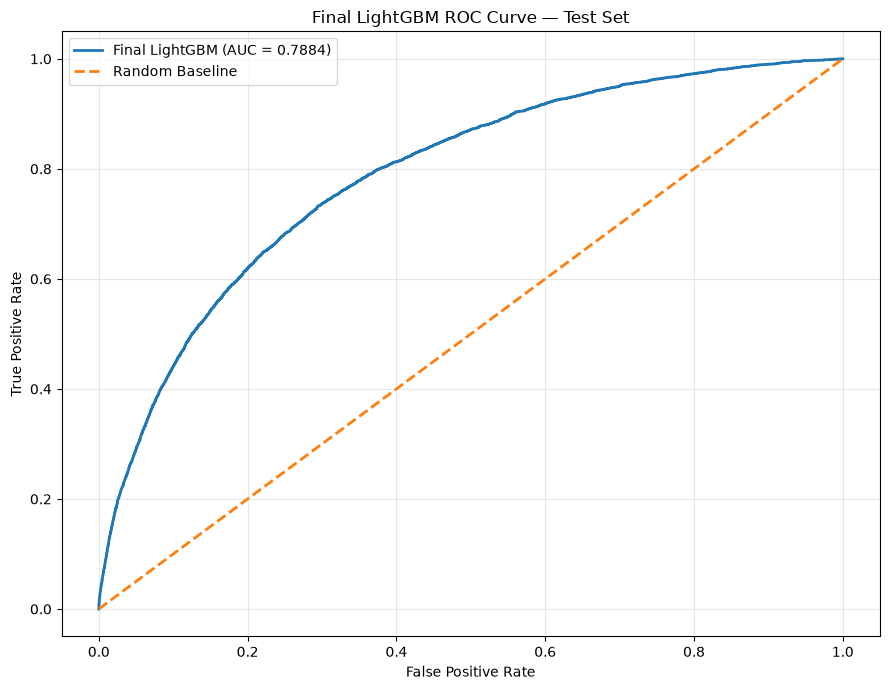

In [10]:
from sklearn.metrics import roc_curve, precision_recall_curve
import matplotlib.pyplot as plt

fpr, tpr, _ = roc_curve(
    y_test,
    y_test_proba
)

plt.figure(figsize=(9, 7))

plt.plot(
    fpr,
    tpr,
    linewidth=2,
    label=f"Final LightGBM (AUC = {test_roc_auc:.4f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    linewidth=2,
    label="Random Baseline"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Final LightGBM ROC Curve — Test Set")

plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

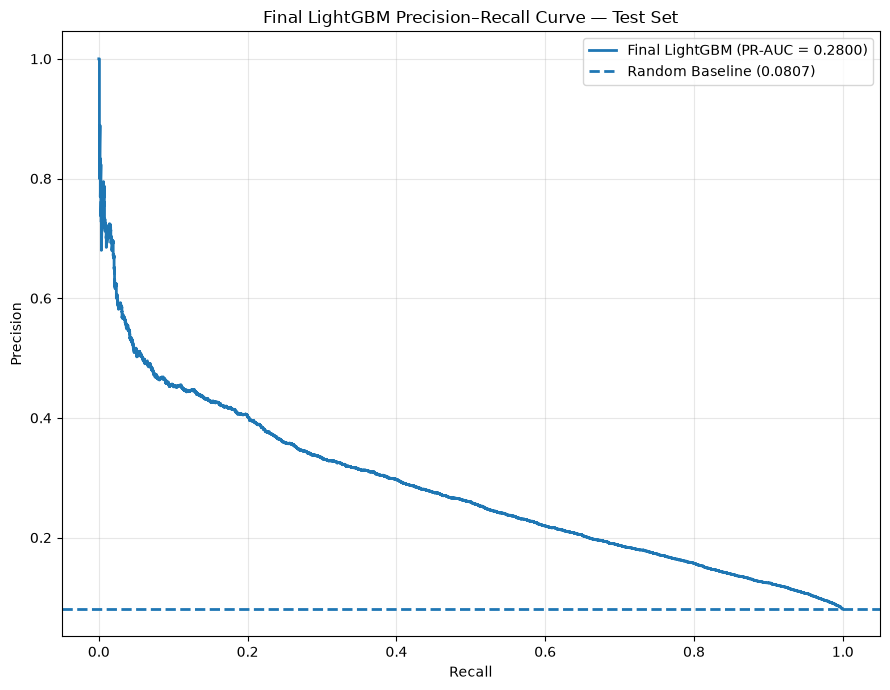

In [11]:
precision, recall, _ = precision_recall_curve(
    y_test,
    y_test_proba
)

baseline = y_test.mean()

plt.figure(figsize=(9, 7))

plt.plot(
    recall,
    precision,
    linewidth=2,
    label=f"Final LightGBM (PR-AUC = {test_pr_auc:.4f})"
)

plt.axhline(
    baseline,
    linestyle="--",
    linewidth=2,
    label=f"Random Baseline ({baseline:.4f})"
)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Final LightGBM Precision–Recall Curve — Test Set")

plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [12]:
import lightgbm as lgb

# Recreate the NB4 selected LightGBM model
lgb_model = lgb.LGBMClassifier(
    objective="binary",
    n_estimators=731,
    learning_rate=0.03,
    num_leaves=31,
    max_depth=-1,
    min_child_samples=50,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=1.0,
    random_state=42,
    n_jobs=-1
)

# Train ONLY on the training split
lgb_model.fit(
    X_train_final,
    y_train
)

# Generate validation probabilities
y_val_proba = lgb_model.predict_proba(
    X_val_final
)[:, 1]

print("Validation predictions generated!")
print("Validation samples:", len(y_val_proba))

[LightGBM] [Info] Number of positive: 14895, number of negative: 169611
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.112724 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 30836
[LightGBM] [Info] Number of data points in the train set: 184506, number of used features: 406
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.080729 -> initscore=-2.432482
[LightGBM] [Info] Start training from score -2.432482
Validation predictions generated!
Validation samples: 61502


Best Validation Threshold: 0.15
Validation Precision: 0.2589
Validation Recall: 0.4592
Validation F1-Score: 0.3311


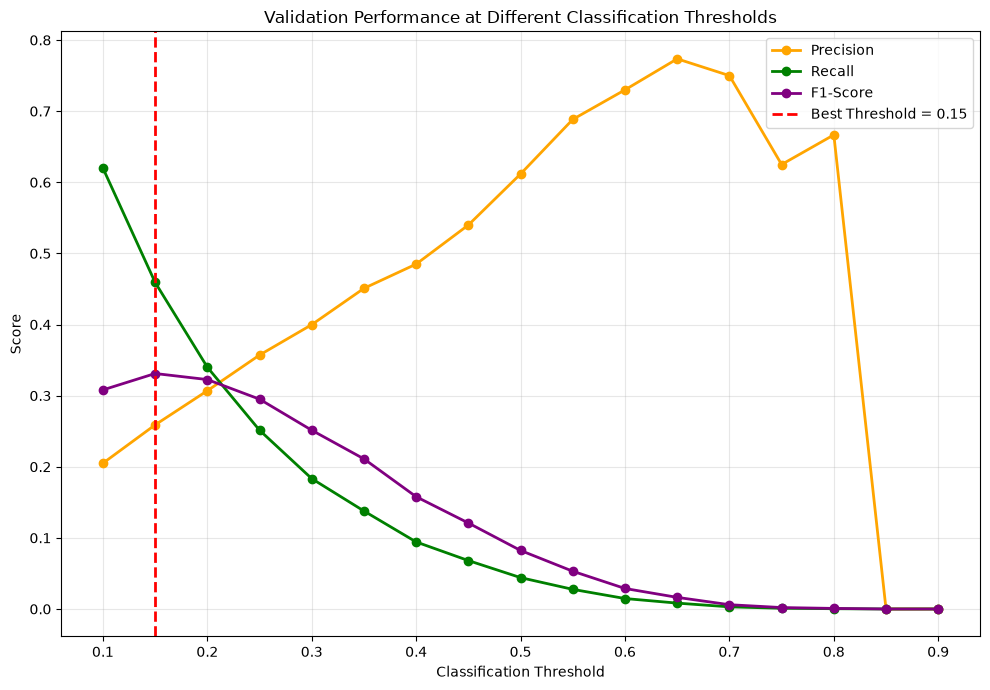

In [13]:
from sklearn.metrics import precision_score, recall_score, f1_score
import numpy as np
import matplotlib.pyplot as plt

thresholds = np.arange(0.10, 0.91, 0.05)

precision_scores = []
recall_scores = []
f1_scores = []

for threshold in thresholds:
    y_val_pred = (y_val_proba >= threshold).astype(int)

    precision_scores.append(
        precision_score(y_val, y_val_pred, zero_division=0)
    )

    recall_scores.append(
        recall_score(y_val, y_val_pred, zero_division=0)
    )

    f1_scores.append(
        f1_score(y_val, y_val_pred, zero_division=0)
    )

best_index = np.argmax(f1_scores)
best_threshold = thresholds[best_index]

print(f"Best Validation Threshold: {best_threshold:.2f}")
print(f"Validation Precision: {precision_scores[best_index]:.4f}")
print(f"Validation Recall: {recall_scores[best_index]:.4f}")
print(f"Validation F1-Score: {f1_scores[best_index]:.4f}")

# Colored graph
plt.figure(figsize=(10, 7))

plt.plot(
    thresholds, precision_scores,
    marker="o",
    color="orange",
    linewidth=2,
    label="Precision"
)

plt.plot(
    thresholds, recall_scores,
    marker="o",
    color="green",
    linewidth=2,
    label="Recall"
)

plt.plot(
    thresholds, f1_scores,
    marker="o",
    color="purple",
    linewidth=2,
    label="F1-Score"
)

plt.axvline(
    best_threshold,
    linestyle="--",
    color="red",
    linewidth=2,
    label=f"Best Threshold = {best_threshold:.2f}"
)

plt.xlabel("Classification Threshold")
plt.ylabel("Score")
plt.title("Validation Performance at Different Classification Thresholds")

plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [14]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

# Use the threshold selected on the validation set
final_threshold = best_threshold

# Convert test probabilities into predictions
y_test_pred = (y_test_proba >= final_threshold).astype(int)

# Calculate test metrics
test_accuracy = accuracy_score(y_test, y_test_pred)
test_precision = precision_score(y_test, y_test_pred, zero_division=0)
test_recall = recall_score(y_test, y_test_pred, zero_division=0)
test_f1 = f1_score(y_test, y_test_pred, zero_division=0)

print(f"Final Classification Threshold: {final_threshold:.2f}")
print(f"Test Accuracy:  {test_accuracy:.4f}")
print(f"Test Precision: {test_precision:.4f}")
print(f"Test Recall:    {test_recall:.4f}")
print(f"Test F1-Score:  {test_f1:.4f}")

print("\nClassification Report:")
print(classification_report(
    y_test,
    y_test_pred,
    target_names=["Non-Default", "Default"],
    zero_division=0
))

Final Classification Threshold: 0.15
Test Accuracy:  0.8543
Test Precision: 0.2687
Test Recall:    0.4679
Test F1-Score:  0.3414

Classification Report:
              precision    recall  f1-score   support

 Non-Default       0.95      0.89      0.92     56538
     Default       0.27      0.47      0.34      4965

    accuracy                           0.85     61503
   macro avg       0.61      0.68      0.63     61503
weighted avg       0.90      0.85      0.87     61503



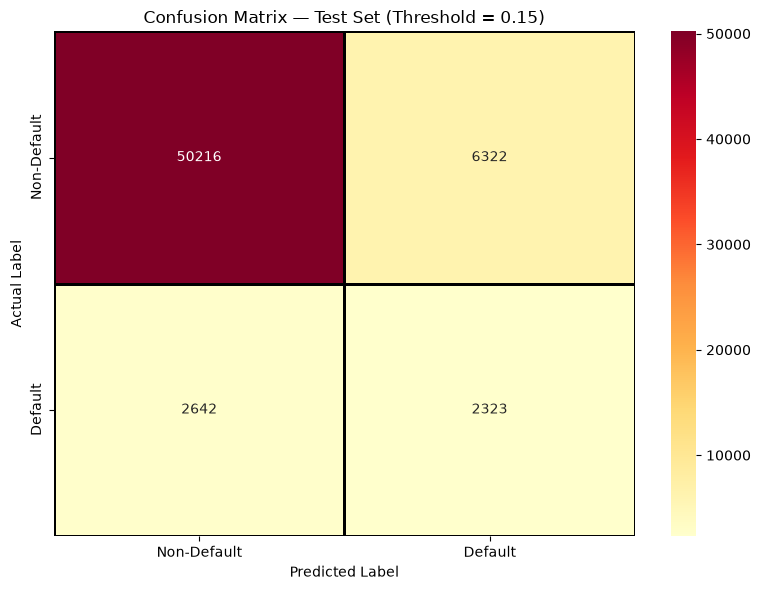

In [15]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_test_pred)

plt.figure(figsize=(8, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="YlOrRd",
    linewidths=1,
    linecolor="black",
    xticklabels=["Non-Default", "Default"],
    yticklabels=["Non-Default", "Default"]
)

plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title(f"Confusion Matrix — Test Set (Threshold = {final_threshold:.2f})")

plt.tight_layout()
plt.show()

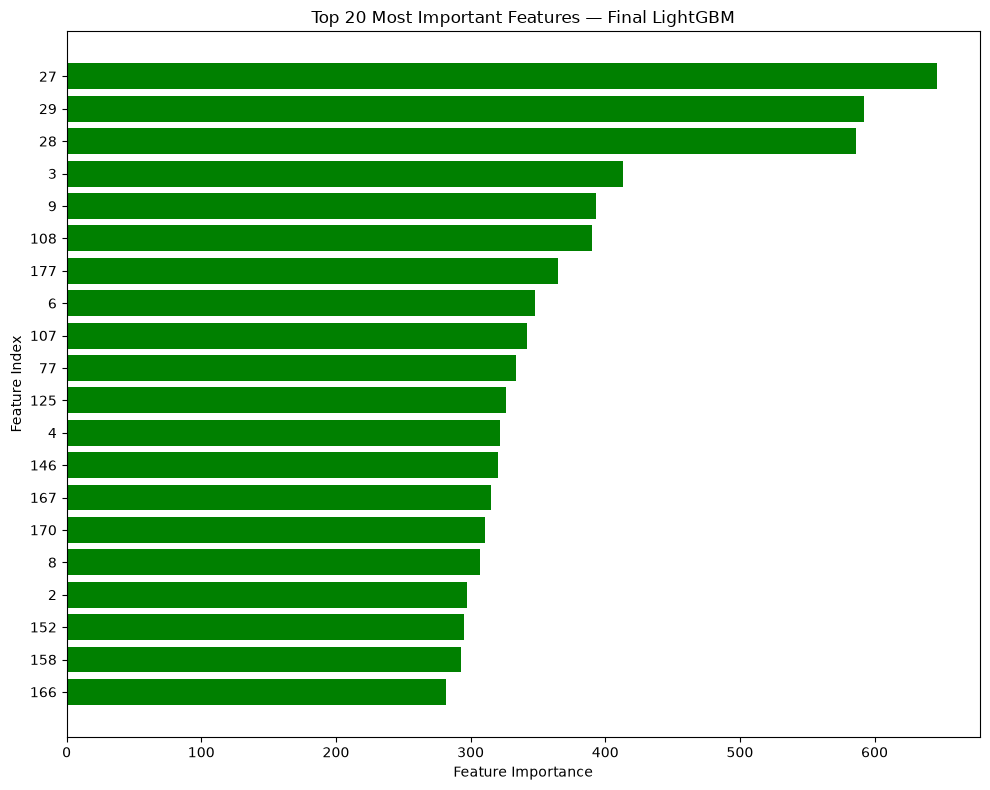

In [16]:
import pandas as pd
import matplotlib.pyplot as plt

# Get feature importance
feature_importance = pd.DataFrame({
    "Feature": range(X_train_final.shape[1]),
    "Importance": final_model.feature_importances_
})

# Select top 20 features
top_features = feature_importance.sort_values(
    "Importance",
    ascending=False
).head(20)

# Plot
plt.figure(figsize=(10, 8))

plt.barh(
    top_features["Feature"].astype(str),
    top_features["Importance"],
    color="green"
)

plt.xlabel("Feature Importance")
plt.ylabel("Feature Index")
plt.title("Top 20 Most Important Features — Final LightGBM")

plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

## Final Model Evaluation — Summary

The final LightGBM model was evaluated on the unseen test set after completing model selection and threshold selection on the validation data.

### Final Test Performance

- **ROC-AUC:** 0.7884
- **PR-AUC:** 0.2800
- **Classification Threshold:** 0.15
- **Accuracy:** 0.8543
- **Precision:** 0.2687
- **Recall:** 0.4679
- **F1-Score:** 0.3414

### Interpretation

The final model achieved a ROC-AUC of 0.7884, indicating good discrimination between default and non-default applicants.

Because the dataset is highly imbalanced, PR-AUC and default-class metrics are particularly important. Using a threshold of 0.15 selected from the validation set, the model achieved a default recall of 46.79%, meaning it identified nearly half of the actual default cases.

The threshold-based evaluation provides a better view of the model's practical performance than using the default 0.50 classification threshold.

### Confusion Matrix

The test-set confusion matrix at the selected threshold produced:

- **True Negatives:** 50,216
- **False Positives:** 6,322
- **False Negatives:** 2,642
- **True Positives:** 2,323

Overall, incorporating historical information from Bureau, Bureau Balance, Previous Applications, Installments, POS Cash Balance, and Credit Card data improved the model compared with using application data alone.

The final LightGBM model is therefore selected as the primary predictive model for the explainable credit-risk assessment system. SHAP-based explainability will be applied in the next notebook to understand the individual and overall factors influencing loan-default predictions.

In [17]:
import joblib

X_train_final = joblib.load("../data/X_train_final_processed.pkl")

feature_names = joblib.load("../data/final_feature_names.pkl")

print("X_train shape:", X_train_final.shape)
print("Feature names:", len(feature_names))

# Check whether feature names are unique
print("Unique feature names:", len(set(feature_names)))

# Find where categorical features begin
cat_indices = [
    i for i, name in enumerate(feature_names)
    if name.startswith("cat__")
]

print("First categorical index:", min(cat_indices))
print("Number of categorical outputs:", len(cat_indices))
print("Number of numerical outputs:", len(feature_names) - len(cat_indices))

X_train shape: (184506, 422)
Feature names: 422
Unique feature names: 422
First categorical index: 282
Number of categorical outputs: 140
Number of numerical outputs: 282


NameError: name 'ColumnTransformer' is not defined